# Section 3: Panel data & pseudo-experiments

### Housekeeping and Data

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
import linearmodels.panel as lmp
import seaborn as sns
from linearmodels.iv import IV2SLS
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

We use data from the ELE panel survey. Variable description follows:  

- *ID*: firm unique identifier  
- *year*: survey year  
- *tamano*: 1 large, 2 medium, 3 small, 4 micro (funcion de las ventas y el numero de trabajadores)  
- *sales*: sales (in log of 1,000 CLP)  
- *age*: firm age at time of survey  
- *foreign*: non-domestic firm (binary)  
- *export*: production for export (binary)  
- *workers*: log of number of workers  
- *fomento*: firm receives public incentives (binary)  
- *iyd*: firm does I+D (binary)  
- *impuestos*: taxes (in million US)  
- *utilidades*: firm revenue (in million US)  


In [13]:
# example data
enia=pd.read_csv('../data/enia.csv')
enia.dropna(inplace=True)
enia.export = enia.export.astype(int)
Xa = enia
bycount = enia['year'].groupby(enia['year']).count()
bIDcount = enia['ID'].groupby(enia['ID']).count()
enia['yr'] = enia['year'].astype(object)
enia = pd.get_dummies(enia)
enia = enia.set_index(["ID","year"])
enia['utilidades']=np.log(enia['utilidades']-enia['utilidades'].min()+0.1)
enia = enia[enia["utilidades"] < 10000]
enia.describe()

,tamano,sales,age,foreign,export,workers,fomento,iyd,impuestos,utilidades
count,39104.000000,39104.000000,39104.000000,39104.000000,39104.000000,39104.000000,39104.000000,39104.000000,39104.000000,39104.000000
mean,2.248773,3.574172,15.305084,0.081859,0.111191,1.757726,0.076105,0.224887,0.203856,5.500845
std,1.153089,1.692742,12.488330,0.274153,0.314372,1.186507,0.265169,0.417514,15.869466,0.060706
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-180.992528,-2.302585
25%,1.000000,2.337643,7.000000,0.000000,0.000000,0.778151,0.000000,0.000000,0.000000,5.499092
50%,2.000000,3.553321,14.000000,0.000000,0.000000,1.785330,0.000000,0.000000,0.000007,5.499092
75%,3.000000,4.539098,20.000000,0.000000,0.000000,2.661813,0.000000,0.000000,0.000167,5.499097
max,4.000000,10.309005,190.000000,1.000000,1.000000,5.845915,1.000000,1.000000,2981.494528,10.729529


## Pooled OLS

In [14]:
#Minimo cuadrado agrupado
y=enia['workers']
X=enia[['sales','age','foreign','export','iyd','utilidades','yr_2009','yr_2013','yr_2015','yr_2017']]
X=sm.add_constant(X)
model = lmp.PanelOLS(y, X)
mco = model.fit()
print(mco)

                          PanelOLS Estimation Summary                           
Dep. Variable:                workers   R-squared:                        0.6173
Estimator:                   PanelOLS   R-squared (Between):              0.6323
No. Observations:               39104   R-squared (Within):               0.4109
Date:              jue., may. 07 2026   R-squared (Overall):              0.6173
Time:                        15:50:38   Log-likelihood                -4.339e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      6306.1
Entities:                       24128   P-value                           0.0000
Avg Obs:                       1.6207   Distribution:                F(10,39093)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             6306.1
                            

## First differences

In [15]:
X=enia[['sales','age','foreign','export','iyd','utilidades','yr_2009','yr_2013','yr_2015','yr_2017']]
model=lmp.FirstDifferenceOLS(y,X)
fd=model.fit(cov_type="robust")
print(fd)

                     FirstDifferenceOLS Estimation Summary                      
Dep. Variable:                workers   R-squared:                        0.4409
Estimator:         FirstDifferenceOLS   R-squared (Between):              0.7419
No. Observations:               14188   R-squared (Within):               0.5529
Date:              jue., may. 07 2026   R-squared (Overall):              0.7419
Time:                        15:50:38   Log-likelihood                -1.194e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      1117.9
Entities:                       24128   P-value                           0.0000
Avg Obs:                       1.6207   Distribution:                F(10,14178)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             794.92
                            

## Fixed Effects 

In [16]:
X=sm.add_constant(X)
model=lmp.PanelOLS(y,X, entity_effects=True)
fe=model.fit(cov_type="robust")
print(fe)

                          PanelOLS Estimation Summary                           
Dep. Variable:                workers   R-squared:                        0.5559
Estimator:                   PanelOLS   R-squared (Between):              0.4194
No. Observations:               39104   R-squared (Within):               0.5559
Date:              jue., may. 07 2026   R-squared (Overall):              0.4233
Time:                        15:50:38   Log-likelihood                   -3479.8
Cov. Estimator:                Robust                                           
                                        F-statistic:                      1873.0
Entities:                       24128   P-value                           0.0000
Avg Obs:                       1.6207   Distribution:                F(10,14966)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             892.28
                            

## Random Effects


In [17]:
model=lmp.RandomEffects(y,X)
re=model.fit(cov_type="robust")
print(re)

                        RandomEffects Estimation Summary                        
Dep. Variable:                workers   R-squared:                        0.5343
Estimator:              RandomEffects   R-squared (Between):              0.6196
No. Observations:               39104   R-squared (Within):               0.4798
Date:              jue., may. 07 2026   R-squared (Overall):              0.6036
Time:                        15:50:39   Log-likelihood                -2.422e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      4485.9
Entities:                       24128   P-value                           0.0000
Avg Obs:                       1.6207   Distribution:                F(10,39093)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             4874.1
                            

In [18]:
re.variance_decomposition

Effects                   0.314164
Residual                  0.182783
Percent due to Effects    0.632189
Name: Variance Decomposition, dtype: float64

## Model comparison

In [19]:
print(lmp.compare({"FE": fe, "RE": re, "Pooled": mco}))

                           Model Comparison                           
                                   FE                RE         Pooled
----------------------------------------------------------------------
Dep. Variable                 workers           workers        workers
Estimator                    PanelOLS     RandomEffects       PanelOLS
No. Observations                39104             39104          39104
Cov. Est.                      Robust            Robust     Unadjusted
R-squared                      0.5559            0.5343         0.6173
R-Squared (Within)             0.5559            0.4798         0.4109
R-Squared (Between)            0.4194            0.6196         0.6323
R-Squared (Overall)            0.4233            0.6036         0.6173
F-statistic                    1873.0            4485.9         6306.1
P-value (F-stat)               0.0000            0.0000         0.0000
=====================     ===========   ===============   ============
const 

Hausman Test

In [20]:
import numpy.linalg as la
from scipy import stats

def hausman(fe, re):
 diff = fe.params-re.params
 psi = fe.cov - re.cov
 dof = diff.size -1
 W = diff.dot(la.inv(psi)).dot(diff)
 pval = stats.chi2.sf(W, dof)
 return W, dof, pval

htest = hausman(fe, re) 
print("Hausman Test: chi-2 = {0}, df = {1}, p-value = {2}".format(htest[0], htest[1], htest[2]))

Hausman Test: chi-2 = 816.8930431606489, df = 10, p-value = 4.814183287484352e-169


## Correlated Random Effects

In [21]:
X = enia.drop(['workers','tamano','fomento','yr_2009','yr_2013','yr_2015','yr_2017'], axis=1, inplace=False)
Xm = X.groupby(by = 'ID').transform('mean')
Xm.columns = ['m{}'.format(column) for column in Xm.columns]
Xc = pd.merge(enia,Xm, left_index=True, right_index=True)
Y = Xc['workers']
X = Xc[['sales','age','foreign','export','iyd','utilidades','msales','mage','mexport','miyd','mutilidades','yr_2009','yr_2013','yr_2015','yr_2017']]
X=sm.add_constant(X)

model=lmp.RandomEffects(y,X)
cre=model.fit(cov_type="robust")
print(cre)

                        RandomEffects Estimation Summary                        
Dep. Variable:                workers   R-squared:                        0.5622
Estimator:              RandomEffects   R-squared (Between):              0.6252
No. Observations:               39104   R-squared (Within):               0.5420
Date:              jue., may. 07 2026   R-squared (Overall):              0.6229
Time:                        15:50:39   Log-likelihood                -2.301e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      3345.9
Entities:                       24128   P-value                           0.0000
Avg Obs:                       1.6207   Distribution:                F(15,39088)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             4340.1
                            

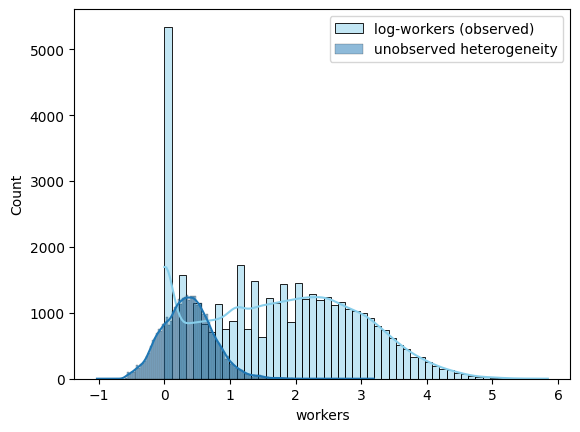

In [22]:
Xpred = X
Xpred['sales']=0
Xpred['age']=0
Xpred['export']=0
Xpred['iyd']=0
Xpred['utilidades']=0
Xpred['foreign']=0
Xpred['yr_2009']=0
Xpred['yr_2013']=0
Xpred['yr_2015']=0
Xpred['yr_2017']=0
yhat = cre.predict(Xpred)

sns.histplot(data=y, color="skyblue", label="log-workers (observed)", kde=True)
sns.histplot(data=yhat, color="red", label="unobserved heterogeneity", kde=True)

plt.legend() 
plt.show()

In [23]:
print(lmp.compare({"FE": fe, "RE": re, "CRE": cre}))

                             Model Comparison                            
                                   FE                RE               CRE
-------------------------------------------------------------------------
Dep. Variable                 workers           workers           workers
Estimator                    PanelOLS     RandomEffects     RandomEffects
No. Observations                39104             39104             39104
Cov. Est.                      Robust            Robust            Robust
R-squared                      0.5559            0.5343            0.5622
R-Squared (Within)             0.5559            0.4798            0.5420
R-Squared (Between)            0.4194            0.6196            0.6252
R-Squared (Overall)            0.4233            0.6036            0.6229
F-statistic                    1873.0            4485.9            3345.9
P-value (F-stat)               0.0000            0.0000            0.0000
=====================     =========== 

### Instrumental Variables

*I&D* es una variable endogena, y podemos considerar a *fomento* y *age* como instrumentos (exogenos) para poder estimar correctamente el efecto de la investigacion y desarrollo sobre el numero de trabajadores (modelo estatico sin considerar efectos temporales).

In [24]:
from statsmodels.api import add_constant
enia = sm.add_constant(enia)
res_ols = IV2SLS(enia.workers, enia[['sales','foreign','export','utilidades','iyd','const']], None, None).fit(
    cov_type="unadjusted")
res_IV = IV2SLS(enia.workers, enia[['sales','foreign','export','utilidades','const']], enia['iyd'], enia[['fomento','age']]).fit(
    cov_type="unadjusted")

from linearmodels.iv import compare
print(compare({"OLS": res_ols, "2SLS": res_IV}))

                 Model Comparison                 
                                OLS           2SLS
--------------------------------------------------
Dep. Variable               workers        workers
Estimator                       OLS        IV-2SLS
No. Observations              39104          39104
Cov. Est.                unadjusted     unadjusted
R-squared                    0.2132         0.0800
Adj. R-squared               0.2131         0.0799
F-statistic                1.06e+04         8729.8
P-value (F-stat)             0.0000         0.0000
==================     ============   ============
sales                        0.2529         0.2408
                           (77.191)       (65.328)
foreign                      0.4031         0.3700
                           (19.791)       (16.668)
export                       0.4124         0.2006
                           (22.856)       (7.6043)
utilidades                  -0.5363        -0.6523
                          (-6.0

#### Instrumental variables with panel data

Primero replicar resultados de arriba pero en modelo de panel (comparar resultados con modelo FE). La libreria tambien permite realizar test de identificacion y exogeneidad (pero presenta problemas computacionales, por eso se aplica en una muestra restringida).

In [25]:

Xa.loc[Xa["year"] > 2012, "year"] = Xa["year"] - 2
Xa['year'] = (Xa['year'] - 2005)/2
Xa = Xa.loc[Xa["ID"] < 200000,] 
Xa.describe()

,ID,year,tamano,sales,age,foreign,export,workers,fomento,iyd,impuestos,utilidades
count,17979.000000,17979.000000,17979.000000,17979.000000,17979.000000,17979.000000,17979.000000,17979.000000,17979.000000,17979.000000,17979.000000,17979.000000
mean,104954.732021,1.934312,2.497469,3.309182,15.870293,0.068135,0.098615,1.447795,0.094277,0.274098,0.397516,1.238478
std,3019.831130,1.271504,1.163482,1.781537,13.654672,0.251985,0.298153,1.176088,0.292221,0.446071,23.379558,29.173261
min,100000.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-180.992528,-244.369760
25%,102265.500000,1.000000,1.000000,2.020092,7.000000,0.000000,0.000000,0.477121,0.000000,0.000000,0.000000,0.000000
50%,104942.000000,1.000000,3.000000,3.077795,14.000000,0.000000,0.000000,1.255273,0.000000,0.000000,0.000003,0.000039
75%,107731.000000,3.000000,4.000000,4.360589,20.000000,0.000000,0.000000,2.281033,0.000000,1.000000,0.000088,0.000788
max,110212.000000,5.000000,4.000000,10.309005,190.000000,1.000000,1.000000,5.513006,1.000000,1.000000,2981.494528,1806.376704


In [28]:
mod = IV2SLS(Xa.workers, sm.add_constant(Xa.sales), Xa.iyd, Xa.fomento)
res = mod.fit(cov_type='unadjusted')
res

IV-2SLS Estimation Summary                          
==============================================================================
Dep. Variable:                workers   R-squared:                      0.3152
Estimator:                    IV-2SLS   Adj. R-squared:                 0.3151
No. Observations:               17979   F-statistic:                    8595.3
Date:              jue., may. 07 2026   P-value (F-stat)                0.0000
Time:                        15:50:56   Distribution:                  chi2(2)
Cov. Estimator:            unadjusted                                         
                                                                              
                             Parameter Estimates                              
==============================================================================
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.0754     0.0228     3.3074     0.0009      0.0307      0.1201
sales          0.3556     0.0049     72.028     0.0000      0.3459      0.3653
iyd            0.7135     0.0953     7.4847     0.0000      0.5267      0.9003
==============================================================================

Endogenous: iyd
Instruments: fomento
Unadjusted Covariance (Homoskedastic)
Debiased: False
IVResults, id: 0x1c195670050